<a href="https://colab.research.google.com/github/fasih779/deep-learning/blob/master/face%20detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import os

# Create kaggle.json
token = {"username":"Fasih Malhi","key":"KGAT_bf3792e51eb22201ee841e352e4447d7"}

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(token, f)

!chmod 600 /root/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 94% 153M/163M [00:00<00:00, 1.60GB/s]
100% 163M/163M [00:00<00:00, 1.48GB/s]


In [3]:
!unzip face-mask-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/with_mask/with_mask_3297.jpg  
  inflating: data/with_mask/with_mask_3298.jpg  
  inflating: data/with_mask/with_mask_3299.jpg  
  inflating: data/with_mask/with_mask_33.jpg  
  inflating: data/with_mask/with_mask_330.jpg  
  inflating: data/with_mask/with_mask_3300.jpg  
  inflating: data/with_mask/with_mask_3301.jpg  
  inflating: data/with_mask/with_mask_3302.jpg  
  inflating: data/with_mask/with_mask_3303.jpg  
  inflating: data/with_mask/with_mask_3304.jpg  
  inflating: data/with_mask/with_mask_3305.jpg  
  inflating: data/with_mask/with_mask_3306.jpg  
  inflating: data/with_mask/with_mask_3307.jpg  
  inflating: data/with_mask/with_mask_3308.jpg  
  inflating: data/with_mask/with_mask_3309.jpg  
  inflating: data/with_mask/with_mask_331.jpg  
  inflating: data/with_mask/with_mask_3310.jpg  
  inflating: data/with_mask/with_mask_3311.jpg  
  inflating: data/with_mask/with_mask_3312.jpg  
  inflating: data/with

In [46]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/data',
    validation_split=0.2,
    subset="training",
    seed=123,
    label_mode='int',
    batch_size=32,
    image_size=(256, 256))
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/data',
    validation_split=0.2,
    subset="validation",
    seed=123,
    label_mode='int',
    batch_size=32,
    image_size=(256, 256))

Found 7553 files belonging to 2 classes.
Using 6043 files for training.
Found 7553 files belonging to 2 classes.
Using 1510 files for validation.


In [47]:
def process(image,label):
    image=tf.cast(image/255,tf.float32)
    return image,label

In [48]:
train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [50]:
print(train_ds.element_spec)

(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [45]:
import tensorflow as tf
from tensorflow import keras

In [17]:
from keras.layers import Input, Lambda, Dense, Flatten,Conv2D,MaxPool2D

In [18]:
from keras import Sequential

In [19]:
train_dt=keras.utils.image_dataset_from_directory(
    directory="/content/cat-and-dog/training_set",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)
test_dt=keras.utils.image_dataset_from_directory(
    directory="/content/cat-and-dog/test_set",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)


NotFoundError: Could not find directory /content/cat-and-dog/training_set

In [7]:
def process(image,label):
    image=tf.cast(image/255,tf.float32)
    return image,label

In [10]:
train_dt=train_dt.map(process)
test_dt=test_dt.map(process)

In [11]:
import tensorflow as tf

In [51]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding="valid",activation="relu",input_shape=(256,256,3)))
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding="valid"))
model.add(Conv2D(64,kernel_size=(3,3),padding="valid",activation="relu"))
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding="valid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.add(Flatten())

In [61]:
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(64,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [62]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])


In [63]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dropout

In [64]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,542,978 (120.33 MB)

 Trainable params: 31,542,978 (120.33 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9930 - loss: 0.0297 - val_accuracy: 0.9113 - val_loss: 0.3995
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9922 - loss: 0.0392 - val_accuracy: 0.9272 - val_loss: 0.3784
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.9892 - loss: 0.0373 - val_accuracy: 0.9278 - val_loss: 0.3548
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.9897 - loss: 0.0340 - val_accuracy: 0.9172 - val_loss: 0.3340
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.9932 - loss: 0.0314 - val_accuracy: 0.9258 - val_loss: 0.3714
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9954 - loss: 0.0257 - val_accuracy: 0.9384 - val_loss: 0.3105
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.9966 - loss: 0.0153 - val_accuracy: 0.9272 - val_loss: 0.3680
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.9979 - loss: 0.0110 - 

In [69]:
import matplotlib.pyplot as plt

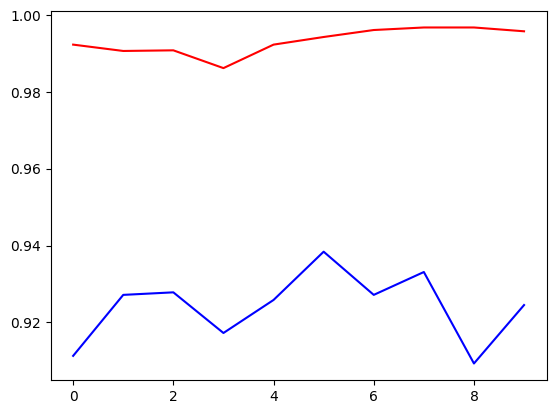

In [70]:
plt.plot(history.history['accuracy'],color="red",label="train")
plt.plot(history.history['val_accuracy'],color="blue",label="validation")

In [72]:
model.save('/content/mask_classifier_model.h5')

In [73]:
from tensorflow.keras.models import load_model

model = load_model('/content/mask_classifier_model.h5')

In [83]:
import cv2
import numpy as np

img_path = '/content/man-wear-face-mask-png-isolated-transparent-background_645927-16866.jpg'
# Load image in BGR format
img = cv2.imread(img_path)

# Convert BGR to RGB (TensorFlow expects RGB)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to your model's input size (here 256x256)
img_resized = cv2.resize(img_rgb, (256, 256))

In [84]:
img_array=img_resized.reshape((1,256,256,3))

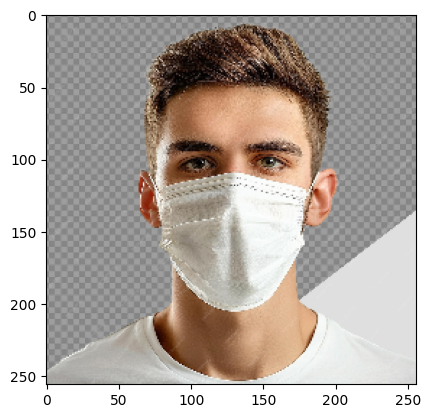

In [75]:
plt.imshow(img_resized)

In [85]:
import numpy as np

# Add a batch dimension to the image array
img_array_batch = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

print(f"Prediction: {pred}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step
Prediction: [[0.00296186]]


In [77]:
img_array = img_resized.astype('float32') / 255.0

In [86]:
import cv2

In [87]:
image_path='/content/OIP.webp'

In [88]:
image_path=cv2.imread(image_path)

In [89]:
image_path=cv2.cvtColor(image_path,cv2.COLOR_BGR2RGB)

In [90]:
image_path=cv2.resize(image_path,(256,256))

In [91]:
image_path=image_path.reshape((1,256,256,3))

In [92]:
pred=model.predict(image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [93]:
pred

array([[0.9982856]], dtype=float32)